In [2]:
with open('shelley-corpus/frankenstein.txt') as f:
    frankenstein = f.read()

In [3]:
import spacy

In [4]:
nlp = spacy.load('en_core_web_lg')

In [5]:
import re

def clean_gutenberg_text(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    start_pattern = r"\*\*\*\s*START OF.*?\*\*\*"
    end_pattern = r"\*\*\*\s*END OF.*?\*\*\*"

    start_match = re.search(start_pattern, text, re.DOTALL | re.IGNORECASE)
    end_match = re.search(end_pattern, text, re.DOTALL | re.IGNORECASE)

    if not start_match or not end_match:
        raise ValueError("Could not locate Gutenberg boundaries.")

    cleaned = text[start_match.end():end_match.start()]

    return cleaned.strip()

In [6]:
frankenstein = clean_gutenberg_text('shelley-corpus/frankenstein.txt')
frank_doc = nlp(frankenstein)

In [7]:
from collections import Counter
freqs = Counter(
            token.lemma_.lower()
            for token in frank_doc
            if (
                not token.is_stop
                and not token.is_punct
                and not token.is_space
            )
        )

In [8]:
freqs

Counter({'man': 181,
         'father': 134,
         'feel': 133,
         'day': 129,
         'friend': 125,
         'life': 124,
         'eye': 122,
         'see': 122,
         'find': 119,
         'time': 109,
         'say': 107,
         'shall': 105,
         'know': 104,
         'place': 103,
         'great': 102,
         'feeling': 99,
         'night': 98,
         'pass': 93,
         'return': 92,
         'elizabeth': 92,
         'mind': 90,
         'love': 89,
         'hear': 87,
         'think': 87,
         'appear': 87,
         'dear': 85,
         'heart': 85,
         'death': 82,
         'long': 82,
         'come': 82,
         'take': 79,
         'soon': 75,
         'hope': 73,
         'remain': 72,
         'creature': 69,
         'look': 68,
         'fear': 66,
         'word': 66,
         'enter': 66,
         'spirit': 65,
         'hand': 65,
         'miserable': 65,
         'like': 63,
         'misery': 63,
         'leave': 62,
     

In [9]:
fear_words = set()

with open("fear_lexicon.txt", "r", encoding="utf-8") as f:
    for line in f:
        word, label = line.strip().split("\t")

        if label == "1":
            fear_words.add(word.lower())

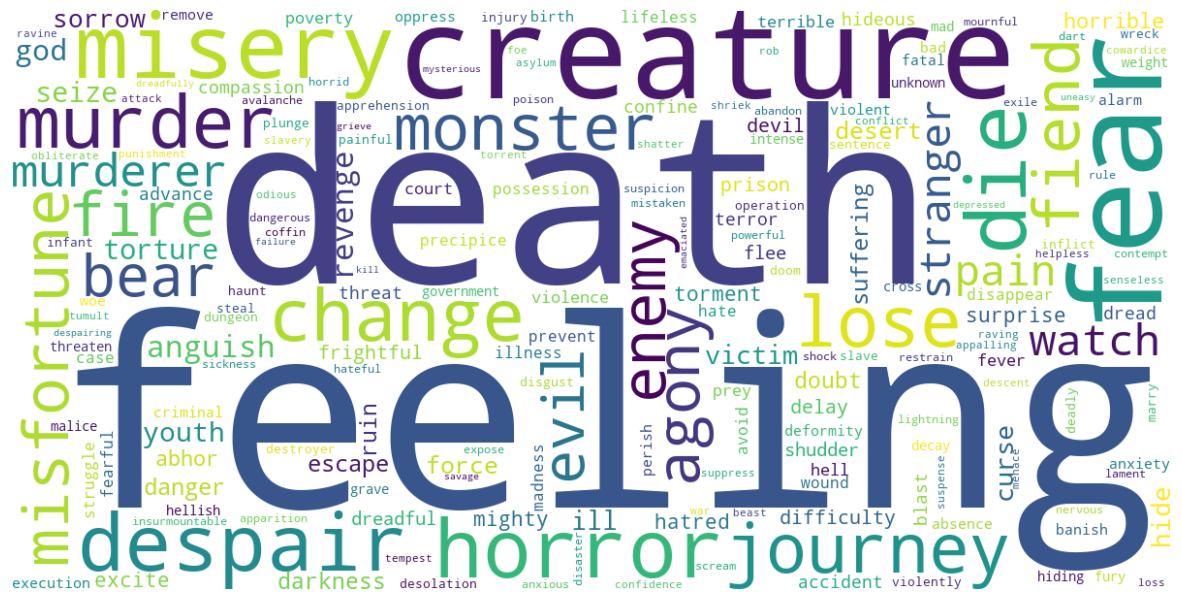

In [10]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load fear lexicon
fear_words = set()

with open("fear_lexicon.txt", "r", encoding="utf-8") as f:
    for line in f:
        word, label = line.strip().split("\t")

        if label == "1":
            fear_words.add(word.lower())

# Count lemmas in Frankenstein
lemma_counts = Counter()

for token in frank_doc:
    if (
        not token.is_punct
        and not token.is_space
        and not token.is_stop
    ):
        lemma = token.lemma_.lower()
        lemma_counts[lemma] += 1

# Keep only fear-related lemmas
fear_counts = {
    lemma: count
    for lemma, count in lemma_counts.items()
    if lemma in fear_words
}

# Generate word cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)

wc.generate_from_frequencies(fear_counts)

plt.figure(figsize=(15, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.savefig(
        f"frankenstein_fear_words.png",
        dpi=300,
        bbox_inches="tight"
    )
plt.show()

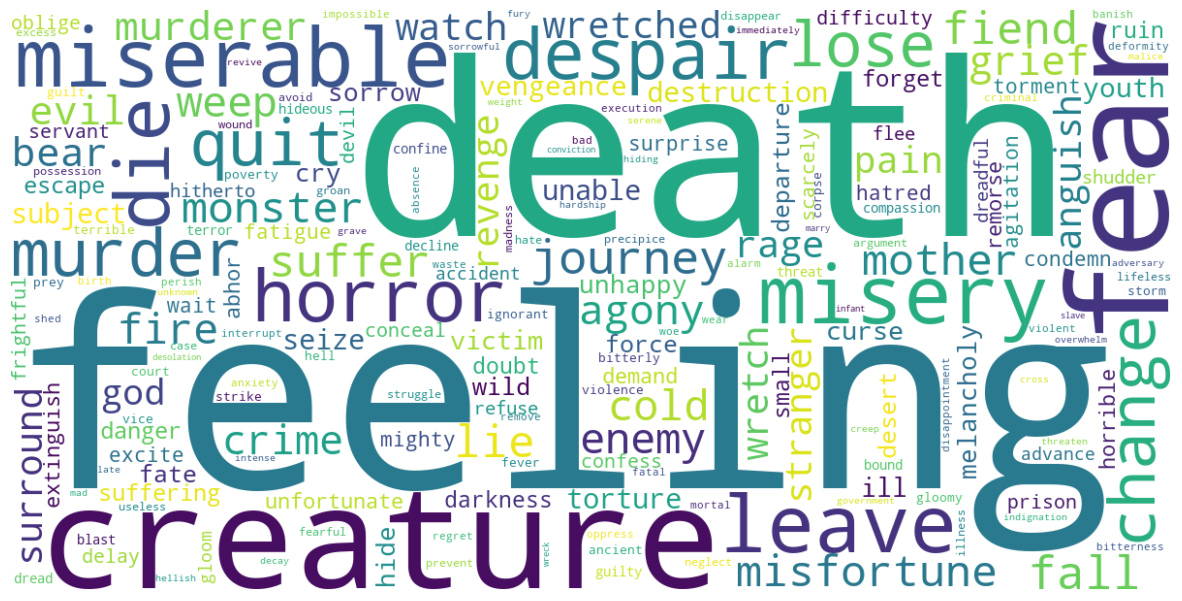

In [11]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

negative_words = set()

with open("negative_lexicon.txt", "r", encoding="utf-8") as f:
    for line in f:
        word, label = line.strip().split("\t")

        if label == "1":
            fear_words.add(word.lower())

# Count lemmas in Frankenstein
lemma_counts = Counter()

for token in frank_doc:
    if (
        not token.is_punct
        and not token.is_space
        and not token.is_stop
    ):
        lemma = token.lemma_.lower()
        lemma_counts[lemma] += 1

# Keep only fear-related lemmas
fear_counts = {
    lemma: count
    for lemma, count in lemma_counts.items()
    if lemma in fear_words
}

# Generate word cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)

wc.generate_from_frequencies(fear_counts)

plt.figure(figsize=(15, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.savefig(
        f"frankenstein_negative_words.png",
        dpi=300,
        bbox_inches="tight"
    )
plt.show()

In [12]:
from collections import Counter

def generate_emotion_dict(lexicon_path, nlp_doc, nlp):
    emotion_words = set()

    with open(lexicon_path, "r", encoding="utf-8") as f:
        for line in f:
            word, label = line.strip().split("\t")
    
            if label == "1":
                lemma = nlp(word)[0].lemma_.lower()
                emotion_words.add(lemma)

    lemma_counts = Counter()

    for token in nlp_doc:
        if (
            not token.is_punct
            and not token.is_space
            and not token.is_stop
        ):
            lemma = token.lemma_.lower()
            lemma_counts[lemma] += 1

    emotion_counts = {
        lemma: count
        for lemma, count in lemma_counts.items()
        if lemma in emotion_words
    }

    return emotion_counts

In [13]:
fear_counts = generate_emotion_dict('fear_lexicon.txt', frank_doc, nlp)

In [14]:
joy_counts = generate_emotion_dict('joy_lexicon.txt', frank_doc, nlp)

In [15]:
sadness_counts = generate_emotion_dict('sadness_lexicon.txt', frank_doc, nlp)

In [16]:
anticipation_counts = generate_emotion_dict('anticipation_lexicon.txt', frank_doc, nlp)

In [17]:
from math import ceil
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def plot_wordcloud_grid(
    frequency_dicts,
    titles,
    cols=2,
    figsize_per_cloud=(6, 4),
    savepath=None
):
    rows = ceil(len(frequency_dicts) / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(
            cols * figsize_per_cloud[0],
            rows * figsize_per_cloud[1]
        )
    )

    axes = axes.flatten()

    for ax, freqs, title in zip(
        axes,
        frequency_dicts,
        titles
    ):
        wc = WordCloud(
            width=800,
            height=400,
            background_color="white"
        ).generate_from_frequencies(freqs)

        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(title)
        ax.axis("off")

    # Hide unused axes
    for ax in axes[len(frequency_dicts):]:
        ax.axis("off")

    plt.tight_layout()

    if savepath:
        plt.savefig(
            f"{savepath}.png",
            dpi=300,
            bbox_inches="tight"
        )
    plt.show()

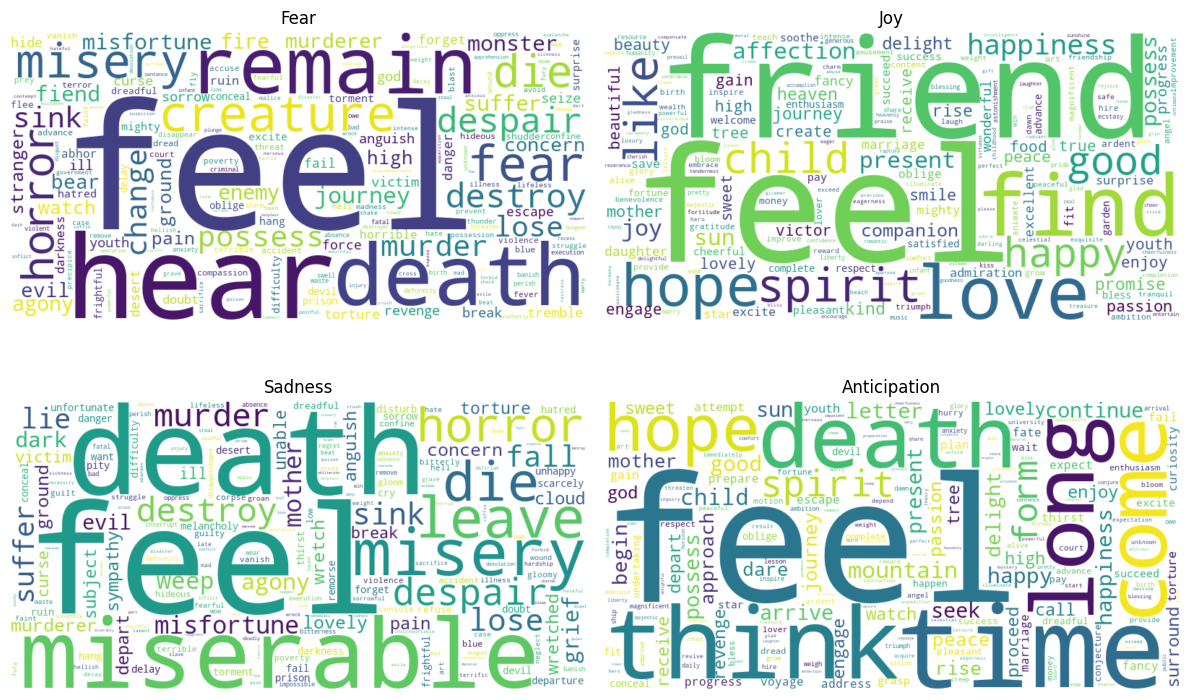

In [18]:
plot_wordcloud_grid(
    [
        fear_counts,
        joy_counts,
        sadness_counts,
        anticipation_counts
    ],
    [
        "Fear",
        "Joy",
        "Sadness",
        "Anticipation"
    ],
    cols=2,
    savepath='frankenstein_emotion_clouds'
)

In [19]:
from math import ceil
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def plot_wordcloud_grid(
    frequency_dicts,
    titles,
    cols=2,
    figure_title=None,
    figsize_per_cloud=(6, 4),
    title_fontsize=18,
    figure_title_fontsize=24,
    hspace=0.05,
    wspace=0.05,
    savepath=None
):

    rows = ceil(len(frequency_dicts) / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(
            cols * figsize_per_cloud[0],
            rows * figsize_per_cloud[1]
        )
    )

    # Handle 1-cloud case
    if not hasattr(axes, "flatten"):
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, freqs, title in zip(
        axes,
        frequency_dicts,
        titles
    ):

        wc = WordCloud(
            width=1200,
            height=800,
            background_color="white"
        ).generate_from_frequencies(freqs)

        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(
            title,
            fontsize=title_fontsize,
            pad=10
        )
        ax.axis("off")

    # Hide unused subplots
    for ax in axes[len(frequency_dicts):]:
        ax.axis("off")

    fig.subplots_adjust(
        hspace=hspace,
        wspace=wspace
    )

    if figure_title:
        fig.suptitle(
            figure_title,
            fontsize=figure_title_fontsize,
            y=0.98
        )

    if savepath:
        plt.savefig(
            f"{savepath}.png",
            dpi=300,
            bbox_inches="tight"
        )    

    plt.show()

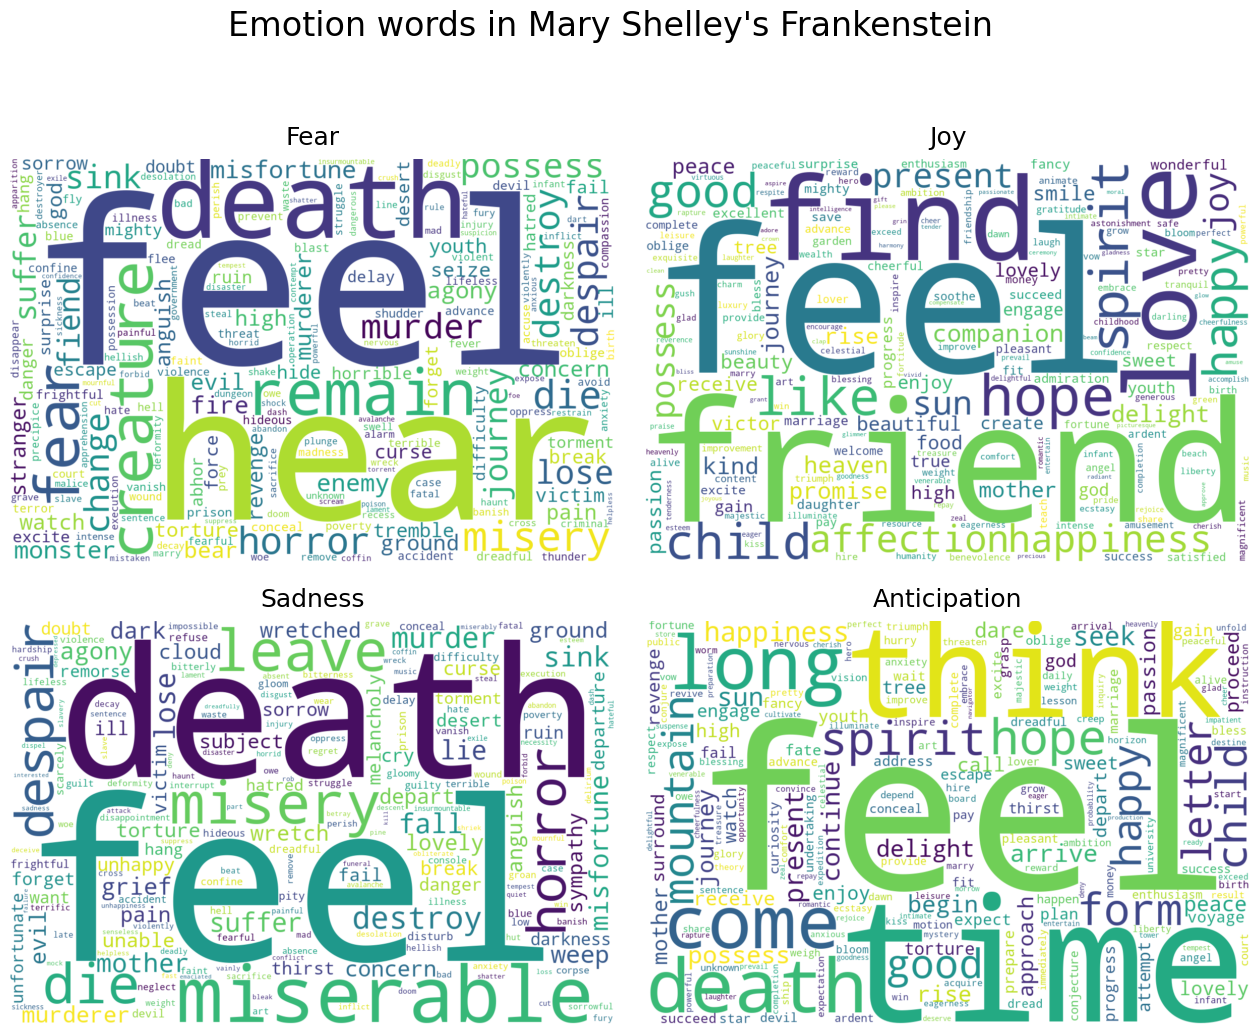

In [20]:
plot_wordcloud_grid(
    [
        fear_counts,
        joy_counts,
        sadness_counts,
        anticipation_counts
    ],
    [
        "Fear",
        "Joy",
        "Sadness",
        "Anticipation"
    ],
    cols=2,
    figure_title="Emotion words in Mary Shelley's Frankenstein",
    figsize_per_cloud=(8, 6),
    hspace=0,
    wspace=0.05,
    savepath='frankenstein_emotion_clouds',  
)